# Compliance with Air Quality Standards

Often, we come across [news](https://www.thehindu.com/news/national/204-of-238-indian-cities-did-not-meet-air-quality-standards-crea/article70712544.ece) that many cities in India do not meet air quality standards.

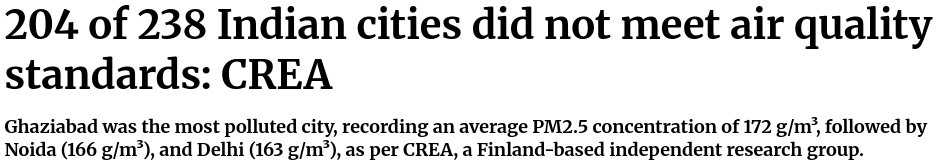

There are two air such air quality standards that are often assessed. The air quality standards provide a upper limit to each pollutant concentration.

1. [National Ambient Air Quality Standards (NAAQS)](https://scclmines.com/env/docs/naaqs-2009.pdf): These are notified by the Central Pollution Control Board (CPCB), in India.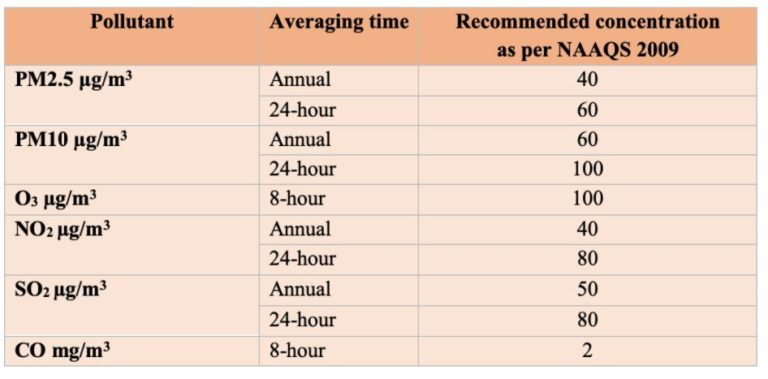
2. [Air quality guidelines](https://www.who.int/news-room/feature-stories/detail/what-are-the-who-air-quality-guidelines): These are notified by the World Health Organisation (W.H.O). These guidelines are much more stringent when compared to NAAQS.  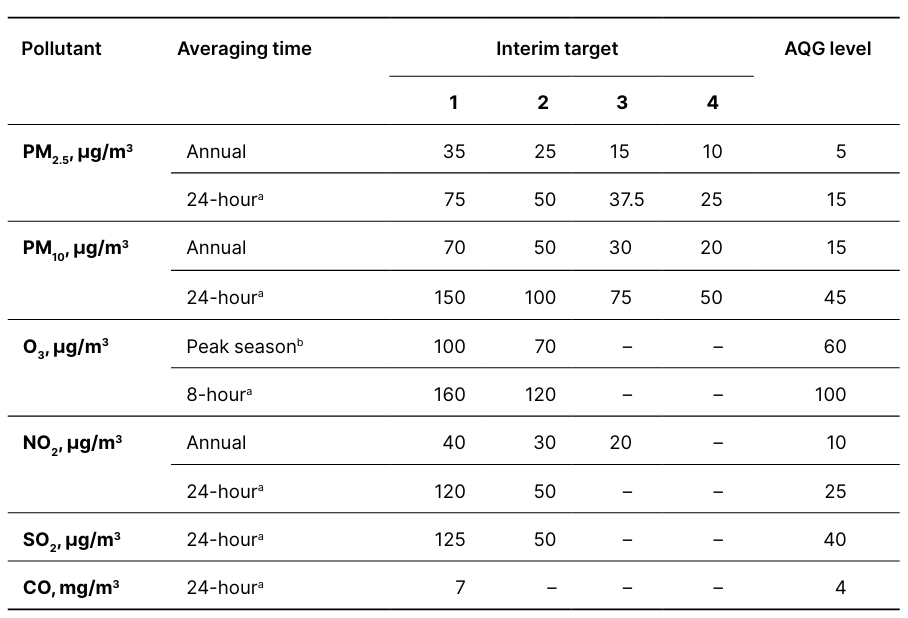

Note that the air quality standards are not based on AQI. They are based on raw pollutant concentrations.

In this tutorial, we will learn to determine if a city is complying with air quality standards (both NAAQS and WHO guidelines) for pollutants `PM2.5`, `PM10`, `NO2` and `SO2`. Only these 4 pollutants have annual standards.

## Dataset

We need data of raw pollutant concentrations of a city. This data can be obtained from the [CPCB's Data Repository](https://airquality.cpcb.gov.in/ccr/#/caaqm-dashboard-all/caaqm-landing/caaqm-data-repository). In this tutorial, we will work with `Hyderabad` data and check if Hyderabad complies with air quality standards. From the data repository, we can download the daily average concentration of each pollutant from each monitoring station in Hyderabad, for the year 2025. 
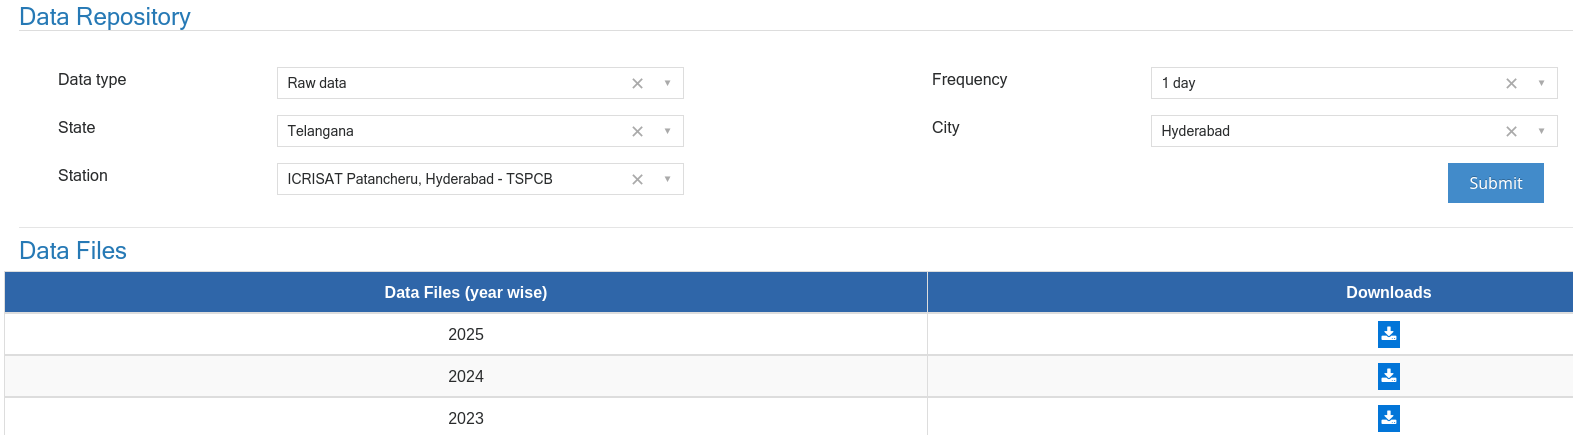

In [126]:
#| code-fold: true
#| code-summary: "Show hidden code that prepares raw concentration daily averages of each station in Hyderabad"
import glob
import pandas as pd
files = glob.glob('data/hyderabad_stations_dailyaverages/Raw*')

dfs = []
for file in files:
    station_name = file.split('_')[8]
    df = pd.read_csv(file)
    df['station'] = station_name
    dfs.append(df)

hyderabad_stations_dailyaverages = pd.concat(dfs)

In [127]:
required_columns = ['Timestamp', 'station','PM2.5 (µg/m³)', 'PM10 (µg/m³)',
       'NO2 (µg/m³)', 'SO2 (µg/m³)' ]

hyderabad_stations_dailyaverages = hyderabad_stations_dailyaverages[required_columns]
hyderabad_stations_dailyaverages = hyderabad_stations_dailyaverages.rename(columns={"PM2.5 (µg/m³)": "PM2.5",
                                                 "PM10 (µg/m³)": "PM10",
                                                "NO2 (µg/m³)":"NO2",
                                                "SO2 (µg/m³)":"SO2"})
hyderabad_stations_dailyaverages.head()

,Timestamp,station,PM2.5,PM10,NO2,SO2
0,2025-01-01 00:00:00,ICRISAT,75.62,145.38,16.29,23.09
1,2025-01-02 00:00:00,ICRISAT,62.54,146.77,16.47,21.68
2,2025-01-03 00:00:00,ICRISAT,60.70,144.88,17.95,20.76
3,2025-01-04 00:00:00,ICRISAT,71.64,165.74,18.88,13.06
4,2025-01-05 00:00:00,ICRISAT,67.12,127.62,12.89,10.43


## Annual average compliance
Checking compliance based on annual averages is a straight forward task. We can calculate the annual average concentration from the daily averages for each pollutant and compare the annual average with the air quality standard. It is only pollutants `PM2.5`, `PM10`, `NO2`, and `SO2` that have annual standards. `SO2` does not have an annual standard in W.H.O guidelines. 

In [157]:
NAAQS_ANNUAL = {'PM2.5':40, 'PM10':60, 'NO2':40, 'SO2':50}
WHO_ANNUAL = {'PM2.5':5, 'PM10':15, 'NO2':10}

The above data is station level daily average data. To check compliance with air quality standards, we need city-level averages.

In [129]:
hyderabad_city_dailyaverages = hyderabad_stations_dailyaverages.groupby('Timestamp')[['PM2.5','PM10','NO2', 'SO2']].mean()
hyderabad_city_dailyaverages.head()

,PM2.5,PM10,NO2,SO2
Timestamp,,,,
2025-01-01 00:00:00,47.557857,103.451538,22.214286,11.124286
2025-01-02 00:00:00,43.112143,104.064615,23.777857,14.044286
2025-01-03 00:00:00,41.000769,103.462500,29.124615,14.409231
2025-01-04 00:00:00,42.022857,107.634615,25.560000,12.781429
2025-01-05 00:00:00,44.377692,100.313333,21.624615,10.005385


The only condition to check as per NAAQS is that there are a minimum of `104 measurements` to calculate the annual average. Since our data is from Continous Ambient Air Quality Monitors (CAAQMS), this condition would be met.

In [130]:
hyderabad_city_dailyaverages.count()

PM2.5    365
PM10     365
NO2      365
SO2      365
dtype: int64

In [131]:
hyderabad_city_annualaverage = hyderabad_city_dailyaverages.mean().reset_index()
hyderabad_city_annualaverage.columns = ['pollutant', 'annual_avg']
hyderabad_city_annualaverage

,pollutant,annual_avg
0,PM2.5,35.545039
1,PM10,82.764408
2,NO2,18.095544
3,SO2,9.807129


We can just compare these annual averages with the NAAQS and W.H.O guidelines now to check if Hyderabad's annual average pollution complies with air quality standards. 

In [132]:
hyderabad_city_annualaverage['NAAQS'] = hyderabad_city_annualaverage.apply(
    lambda x: 'N/A' if x['pollutant'] not in NAAQS_ANNUAL else ('Yes' if x['annual_avg'] < NAAQS_ANNUAL[x['pollutant']] else 'No'),
    axis=1
)

hyderabad_city_annualaverage['WHO'] = hyderabad_city_annualaverage.apply(
    lambda x: 'N/A' if x['pollutant'] not in WHO_ANNUAL else ('Yes' if x['annual_avg'] < WHO_ANNUAL[x['pollutant']] else 'No'),
    axis=1
)
hyderabad_city_annualaverage

,pollutant,annual_avg,NAAQS,WHO
0,PM2.5,35.545039,Yes,No
1,PM10,82.764408,No,No
2,NO2,18.095544,Yes,No
3,SO2,9.807129,Yes,N/A


Hyderabad's air quality did not meet any of the W.H.O guidelines. It met NAAQS guidelines for `PM2.5`, `NO2`, `SO2` and failed to meet `PM10` guideline. This gives some policy insight that Hyderabad should focus more on cutting `PM10`. 

## Daily average compliance

Annual averages could be misleading as we breathe air every day. A couple of months of high pollution along with clean air in remaining months would result in a low annual average. But, our health would still get affected. Hence, the air quality standards have daily averages as well. As per NAAQS, a city should meet these daily averages on `98% of the days` and on `no two consecutive days` should a city miss the standard.

As per W.H.O, a city should meet these daily averages on `99% of the days`.

Note: `O3` and `CO` require Daily Maximum 8-hour average concentrations for comparison.

In [156]:
NAAQS_DAILY = {'PM2.5':60, 'PM10':100, 'NO2':80, 'SO2':80}
WHO_DAILY = {'PM2.5':15, 'PM10':45, 'NO2':25, 'SO2':40}

In [149]:
#Calculate 98th percentile of each pollutant concentration
hyderabad_city_percentiles = hyderabad_city_dailyaverages.quantile(0.98).reset_index()  # 98th percentile
hyderabad_city_percentiles.columns = ['pollutant', '98th_pct']

hyderabad_city_percentiles

,pollutant,98th_pct
0,PM2.5,52.443343
1,PM10,110.660585
2,NO2,27.319477
3,SO2,14.044523


In [150]:
# Checking if air quality crossed NAAQS standards on two consecutive days
for idx,row in hyderabad_city_percentiles.iterrows():
    pollutant = row['pollutant']
    
    daily_averages = hyderabad_city_dailyaverages[pollutant] #Daily city-averages of pollutant

    # Checking if city missed the NAAQS on a day
    daily_averages_cross_NAAQS = daily_averages > NAAQS_DAILY[pollutant]

    #Checking if city missed the NAAQS on two consecutive days
    has_consecutive = daily_averages_cross_NAAQS.rolling(2).sum().eq(2).any()
    
    hyderabad_city_percentiles.loc[idx, 'consecutive_fail'] = has_consecutive

hyderabad_city_percentiles

,pollutant,98th_pct,consecutive_fail
0,PM2.5,52.443343,False
1,PM10,110.660585,True
2,NO2,27.319477,False
3,SO2,14.044523,False


In [158]:
# Check NAAQS Compliance
hyderabad_city_percentiles['NAAQS'] = hyderabad_city_percentiles.apply(
    lambda x: 'N/A' if x['pollutant'] not in NAAQS_DAILY else ('Yes' if x['98th_pct'] < NAAQS_DAILY[x['pollutant']] else 'No'),
    axis=1
)
hyderabad_city_percentiles

,pollutant,98th_pct,consecutive_fail,NAAQS,99th_pct,WHO
0,PM2.5,52.443343,False,Yes,55.085321,No
1,PM10,110.660585,True,No,114.056215,No
2,NO2,27.319477,False,Yes,28.532114,No
3,SO2,14.044523,False,Yes,14.466769,Yes


In [159]:
#Calculate 99th percentile - for WHO guideline
hyderabad_city_percentiles['99th_pct'] = hyderabad_city_dailyaverages.quantile(0.99).reset_index()[0.99]
hyderabad_city_percentiles

,pollutant,98th_pct,consecutive_fail,NAAQS,99th_pct,WHO
0,PM2.5,52.443343,False,Yes,55.085321,No
1,PM10,110.660585,True,No,114.056215,No
2,NO2,27.319477,False,Yes,28.532114,No
3,SO2,14.044523,False,Yes,14.466769,Yes


In [160]:
hyderabad_city_percentiles['WHO'] = hyderabad_city_percentiles.apply(
    lambda x: 'N/A' if x['pollutant'] not in WHO_DAILY else ('Yes' if x['98th_pct'] < WHO_DAILY[x['pollutant']] else 'No'),
    axis=1
)
hyderabad_city_percentiles

,pollutant,98th_pct,consecutive_fail,NAAQS,99th_pct,WHO
0,PM2.5,52.443343,False,Yes,55.085321,No
1,PM10,110.660585,True,No,114.056215,No
2,NO2,27.319477,False,Yes,28.532114,No
3,SO2,14.044523,False,Yes,14.466769,Yes


With daily averages, Hyderabad's air quality met WHO guideline only for `SO2` and not for any other pollutant. This could be because there is no thermal power plant inside Hyderabad city.

As with annual averages, it met NAAQS guidelines for `PM2.5`, `NO2` and `SO2` and failed to meet `PM10` guideline.

We can also analyse this compliance as the number of days on which residents of Hyderabad breathed unhealthy air

In [163]:
print("In 2025, residents of Hyderabad breathed air that is not complaint with NAAQS for \n")
for idx,row in hyderabad_city_percentiles.iterrows():
    pollutant = row['pollutant']
    
    daily_averages = hyderabad_city_dailyaverages[pollutant] #Daily city-averages of pollutant
    
    # Checking if city missed the NAAQS on a day
    daily_averages_cross_NAAQS = daily_averages > NAAQS_DAILY[pollutant]
    num_days = daily_averages_cross_NAAQS.sum()
    
    print(f"{num_days} days for {pollutant} pollutant \n")

In 2025, residents of Hyderabad breathed air that is not complaint with NAAQS for 

2 days for PM2.5 pollutant 

70 days for PM10 pollutant 

0 days for NO2 pollutant 

0 days for SO2 pollutant 



In [164]:
print("In 2025, residents of Hyderabad breathed air that is not complaint with W.H.O for \n")
for idx,row in hyderabad_city_percentiles.iterrows():
    pollutant = row['pollutant']
    
    daily_averages = hyderabad_city_dailyaverages[pollutant] #Daily city-averages of pollutant
    
    # Checking if city missed the NAAQS on a day
    daily_averages_cross_WHO = daily_averages > WHO_DAILY[pollutant]
    num_days = daily_averages_cross_WHO.sum()
    
    print(f"{num_days} days for {pollutant} pollutant \n")

In 2025, residents of Hyderabad breathed air that is not complaint with W.H.O for 

365 days for PM2.5 pollutant 

365 days for PM10 pollutant 

19 days for NO2 pollutant 

0 days for SO2 pollutant 



## Summary

In this tutorial, we learnt how to check if a city is complying with air quality standards - both NAAQS and W.H.O guidelines. We learnt that this compliance assessment is done using raw concentration data of each pollutant and not AQI. We learnt how to check compliance using both annual averages and daily averages.

It should be noted that we analysed the compliance based on the monitoring data only. The official assessment of a city's performance under the [National Clean Air Program (NCAP)](https://urbanemissions.info/india-air-quality/india-ncap-cities/) also happens on the basis of monitoring data alone. In the previous tutorial we learnt that monitoring network of a city can spatially under-represent a city. That limitation would apply in this analysis as well. 